In [ ]:
!pip install bertopic
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink

In [ ]:
import pandas as pd
import numpy as np
from bertopic import BERTopic
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict
from sentence_transformers import SentenceTransformer

In [ ]:
# gunakan embedding model dari IndoBERT
embedding_model = SentenceTransformer("indobenchmark/indobert-base-p1")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# import data
df = pd.read_csv('/content/result_2.csv')
df

# filter
df_filtered = df[df['title'] == 'RSUD Bung Karno Kota Surakarta']
display(df_filtered)

,title,stars,text,bin_pelayanan,bin_fasilitas,predicted_labels_1,labels,prob_layanan,prob_fasilitas
1106,RSUD Bung Karno Kota Surakarta,1,first impression disituuuu juelekk puolll di i...,1,0,['pelayanan'],negative,0.998603,0.016254
1107,RSUD Bung Karno Kota Surakarta,5,stabil,1,1,"['pelayanan', 'fasilitas']",positive,0.977638,0.974985
1108,RSUD Bung Karno Kota Surakarta,5,alhamdulillah nyaman,0,1,['fasilitas'],positive,0.365189,0.997698
1109,RSUD Bung Karno Kota Surakarta,5,pegawainya ramahramah luar biasa tempatnya nya...,1,1,"['pelayanan', 'fasilitas']",positive,0.994525,0.992881
1110,RSUD Bung Karno Kota Surakarta,5,tempatnya nyaman petugas dan stafnya ramah,1,1,"['pelayanan', 'fasilitas']",positive,0.994573,0.991858
...,...,...,...,...,...,...,...,...,...
1921,RSUD Bung Karno Kota Surakarta,5,bagus besar dan megah terletak di sekitar sili...,1,1,"['pelayanan', 'fasilitas']",positive,0.985932,0.993891
1922,RSUD Bung Karno Kota Surakarta,5,gedung bagus besar luas bersih dan mempesona,0,1,['fasilitas'],positive,0.003595,0.989139
1923,RSUD Bung Karno Kota Surakarta,5,Jempoooollllll,1,1,"['pelayanan', 'fasilitas']",positive,0.988729,0.898661
1924,RSUD Bung Karno Kota Surakarta,5,rsud bung karno rumah sakit baru yang terletak...,0,1,['fasilitas'],positive,0.009821,0.979070


In [ ]:
# menghapus stopwords
import re

# daftar
stopwords = ['saya', 'yg', 'dan', 'yang', 'di', 'tidak', 'juga', 'utk', 'itu',
             'untuk', 'juga', 'jg', 'nya', 'tapi', 'tp', 'ga', 'gak', 'ngga', 'nggak', 'sy', 'lagi',
             'lg', 'dengan', 'dgn', 'dg', 'ini', 'kami', 'apa', 'ada', 'ke', 'ya', 'dong', 'sgt', 'bgt',
             'karena', 'krn', 'sebagai', 'sbg', 'dari', 'malah']

# function
def remove_stopwords(text):
    if isinstance(text, str):  # make sure string
        pattern = r'\b(?:' + '|'.join(stopwords) + r')\b'
        return re.sub(pattern, '', text, flags=re.IGNORECASE).strip()
    return text


df_filtered['text'] = df_filtered['text'].apply(remove_stopwords)

# Kategori

In [ ]:
# insialisasi model untuk dua kategori
layanan_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)
fasilitas_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan probabilitas kategori
def assign_reviews_by_category(data, threshold=0.5):
    layanan_reviews = []
    fasilitas_reviews = []
    layanan_indices = []
    fasilitas_indices = []
    for idx, row in data.iterrows():
        if row['prob_layanan'] >= threshold:
            layanan_reviews.append(row['text'])
            layanan_indices.append(idx)
        if row['prob_fasilitas'] >= threshold:
            fasilitas_reviews.append(row['text'])
            fasilitas_indices.append(idx)
    return layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices

# Memisahkan ulasan (ulasan dengan prob 0.99 masuk ke kedua kategori)
layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices = assign_reviews_by_category(df_filtered, threshold=0.5)

In [ ]:
# Pemodelan topik untuk kategori layanan
if layanan_reviews:
    topics_layanan, probs_layanan = layanan_model.fit_transform(layanan_reviews)
else:
    topics_layanan, probs_layanan = [], []

In [ ]:
# Pemodelan topik untuk kategori fasilitas
if fasilitas_reviews:
    topics_fasilitas, probs_fasilitas = fasilitas_model.fit_transform(fasilitas_reviews)
else:
    topics_fasilitas, probs_fasilitas = [], []

In [ ]:
# layanan_model.update_topics(layanan_reviews, top_n_words=10)  # Batasi ke 10 kata
# fasilitas_model.update_topics(fasilitas_reviews, top_n_words=10)  # Batasi ke 10 kata

## Hasil topic modelling

In [ ]:
# melihat total topic layanan
print(len(layanan_model.get_topics()))

# melihat total topic fasilitas
print(len(fasilitas_model.get_topics()))

5
2


In [ ]:
layanan_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,238,-1_pelayanan_ramah_sangat_baik,"[pelayanan, ramah, sangat, baik, bersih, bagus...","[pelayanan sangat baik, pelayanan sangat baik,..."
1,0,350,0_ramah_pelayanan_sangat_baik,"[ramah, pelayanan, sangat, baik, bersih, cepat...","[sangat cepat pelayanan ramah, pelayanan cepa..."
2,1,84,1_jkn_mudah_rsbk_lebih,"[jkn, mudah, rsbk, lebih, pelayanan, memakai, ...",[pelayanan rsud bung karno bagus dokternya ram...
3,2,48,2_bagus_sehat_terimakasih_setia,"[bagus, sehat, terimakasih, setia, sahabat, se...","[Bagus, sahabat setia sehat, sahabat setia s..."
4,3,44,3_jam_dokter_bisa_pasien,"[jam, dokter, bisa, pasien, baru, sudah, nungg...",[syaa igd beberapa keluhan salah satunya ses...


In [ ]:
fasilitas_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,32,0_bagus_sehat_terimakasih_setia,"[bagus, sehat, terimakasih, setia, joss, stabi...","[bagus, Bagus, bagus]"
1,1,336,1_ramah_bersih_pelayanan_rumah,"[ramah, bersih, pelayanan, rumah, sangat, nyam...",[rumah sakit pelayanan ramah fasilitas lengka...


## Frekuensi sentimen dari setiap topik

In [ ]:
import numpy as np
import pandas as pd

# === Analisis Topik & Sentimen untuk Layanan ===
# Pastikan indeks valid
layanan_indices_valid = np.intersect1d(layanan_indices, df_filtered.index)

df_layanan = df_filtered.loc[layanan_indices_valid].copy()
df_layanan["topic"] = topics_layanan[:len(df_layanan)]  # pastikan panjang sama

df_layanan = df_layanan[df_layanan['topic'] != -1]
topic_sentiment_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'])
emotion_dist_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'], normalize='index')

print("=== Distribusi Sentimen per Topik (Layanan) ===")
print(topic_sentiment_layanan)
print("\n=== Proporsi Sentimen per Topik (Layanan) ===")
print(emotion_dist_layanan)


# === Analisis Topik & Sentimen untuk Fasilitas ===
# Pastikan indeks valid
fasilitas_indices_valid = np.intersect1d(fasilitas_indices, df_filtered.index)

df_fasilitas = df_filtered.loc[fasilitas_indices_valid].copy()
df_fasilitas["topic"] = topics_fasilitas[:len(df_fasilitas)]  # pastikan panjang sama

df_fasilitas = df_fasilitas[df_fasilitas['topic'] != -1]
topic_sentiment_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'])
emotion_dist_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'], normalize='index')

print("\n=== Distribusi Sentimen per Topik (Fasilitas) ===")
print(topic_sentiment_fasilitas)
print("\n=== Proporsi Sentimen per Topik (Fasilitas) ===")
print(emotion_dist_fasilitas)


=== Distribusi Sentimen per Topik (Layanan) ===
labels  negative  neutral  positive
topic                              
0              9        4       337
1              2       10        72
2              2        3        43
3             39        2         3

=== Proporsi Sentimen per Topik (Layanan) ===
labels  negative   neutral  positive
topic                               
0       0.025714  0.011429  0.962857
1       0.023810  0.119048  0.857143
2       0.041667  0.062500  0.895833
3       0.886364  0.045455  0.068182

=== Distribusi Sentimen per Topik (Fasilitas) ===
labels  negative  neutral  positive
topic                              
0              0        2        30
1             34       11       291

=== Proporsi Sentimen per Topik (Fasilitas) ===
labels  negative   neutral  positive
topic                               
0        0.00000  0.062500  0.937500
1        0.10119  0.032738  0.866071


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

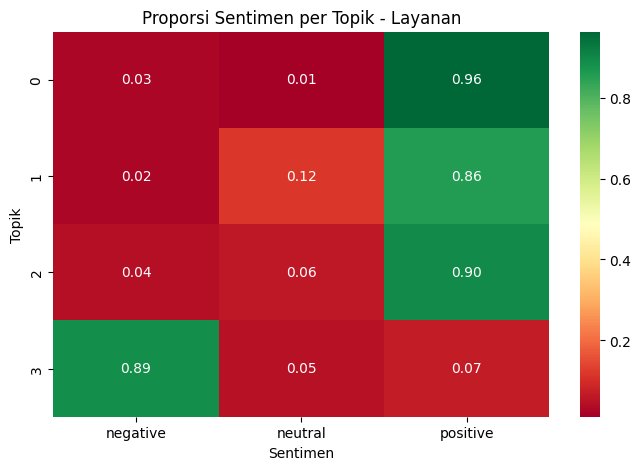

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_layanan, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Layanan")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

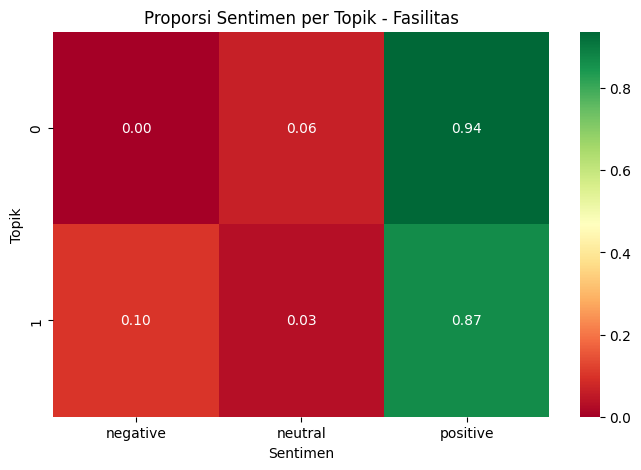

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_fasilitas, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Fasilitas")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

In [ ]:
# Fungsi untuk menampilkan kata kunci tiap topik
def tampilkan_topik(model, kategori):
    topics = model.get_topics()
    print(f"=== Topik untuk kategori {kategori} ===")
    for topic_id, topic_info in topics.items():
        print(f"Topic {topic_id}:")
        print(f"Representasi: {topic_info}")
        print("-" * 50)
    print("\n")

# Panggil untuk layanan dan fasilitas
tampilkan_topik(layanan_model, "Layanan")
tampilkan_topik(fasilitas_model, "Fasilitas")

=== Topik untuk kategori Layanan ===
Topic -1:
Representasi: [('pelayanan', np.float64(0.07566643704699053)), ('ramah', np.float64(0.06362359809629052)), ('sangat', np.float64(0.05921959156325796)), ('baik', np.float64(0.056175743822144936)), ('bersih', np.float64(0.05178796557871324)), ('bagus', np.float64(0.04212087867068677)), ('rumah', np.float64(0.04038696932346024)), ('semua', np.float64(0.033661999575174004)), ('pasien', np.float64(0.03360937154669551)), ('dokter', np.float64(0.03356742579529245))]
--------------------------------------------------
Topic 0:
Representasi: [('ramah', np.float64(0.09757065951038907)), ('pelayanan', np.float64(0.09088171123369893)), ('sangat', np.float64(0.06823662706213741)), ('baik', np.float64(0.06478172207157792)), ('bersih', np.float64(0.05883698095107505)), ('cepat', np.float64(0.05671162012920875)), ('bung', np.float64(0.05528871039696456)), ('pelayanannya', np.float64(0.054828641172589426)), ('karno', np.float64(0.053219691526766505)), ('rsu

# Sentimen

In [ ]:
# insialisasi model untuk dua sentimen
positive_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=8)
negative_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=6)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan sentimen
def assign_reviews_by_sentiment(data):
    positif_reviews = data[data['labels'] == 'positive']['text'].tolist()
    negatif_reviews = data[data['labels'] == 'negative']['text'].tolist()
    positif_indices = data[data['labels'] == 'positive'].index.tolist()
    negatif_indices = data[data['labels'] == 'negative'].index.tolist()
    return positif_reviews, negatif_reviews, positif_indices, negatif_indices

In [ ]:
# Memisahkan ulasan berdasarkan sentimen
positif_reviews, negatif_reviews, positif_indices, negatif_indices = assign_reviews_by_sentiment(df_filtered)

In [ ]:
# Pemodelan topik untuk sentimen positif
if positif_reviews:
    topics_positif, probs_positif = positive_model.fit_transform(positif_reviews)
else:
    topics_positif, probs_positif = [], []

In [ ]:
# Pemodelan topik untuk sentimen negatif
if negatif_reviews:
    topics_negatif, probs_negatif = negative_model.fit_transform(negatif_reviews)
else:
    topics_negatif, probs_negatif = [], []

## Hasil Topic Modelling

In [ ]:
# melihat total topic positive
print(len(positive_model.get_topics()))

# melihat total topic negative
print(len(negative_model.get_topics()))

8
3


In [ ]:
positive_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,148,-1_pelayanan_baik_sangat_ramah,"[pelayanan, baik, sangat, ramah, bersih, rsud,...","[pelayanan sangat baik, pelayanan sangat baik,..."
1,0,47,0_bagus_sehat_terimakasih_setia,"[bagus, sehat, terimakasih, setia, sahabat, se...",[mantap pelayanan ramah bintang lima sahabat s...
2,1,134,1_pelayanan_ramah_cepat_pelayanannya,"[pelayanan, ramah, cepat, pelayanannya, bagus,...","[petugas ramah pelayanan cepat memuaskan, san..."
3,2,17,2_rsbk_pelayanan_rs_rumah,"[rsbk, pelayanan, rs, rumah, sakit, parinem, p...","[pelayanan rsbk memuaskan, pelayanan rsbk san..."
4,3,194,3_ramah_rumah_bersih_nyaman,"[ramah, rumah, bersih, nyaman, sakit, pelayana...",[rumah sakitnya sangat bersih pegawainya ramah...
5,4,55,4_jkn_mudah_lebih_rsbk,"[jkn, mudah, lebih, rsbk, memakai, pelayanan, ...",[pelayanan rsud bung karno bagus dokternya ram...
6,5,47,5_bung_karno_rsud_memuaskan,"[bung, karno, rsud, memuaskan, sangat, pelayan...",[pelayanan rsud bung karno sangat baik sekali ...
7,6,53,6_dokter_sangat_pelayanan_semua,"[dokter, sangat, pelayanan, semua, perawat, rs...",[stiap kali keluarga skit pasti sarankan ...


In [ ]:
negative_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,33,-1_rs_buat_udah_sakit,"[rs, buat, udah, sakit, pasien, sekali, hari, ...",[min tolong yaaa perawatnya pd ramah buat har...
1,0,16,0_pelayanan_sangat_bagus_bpjs,"[pelayanan, sangat, bagus, bpjs, semua, lama, ...",[pelayanan rs rawat inap sangat bagus pelayan...
2,1,36,1_jam_sudah_dokter_pasien,"[jam, sudah, dokter, pasien, bisa, baru, setel...",[syaa igd beberapa keluhan salah satunya ses...


In [ ]:
# Panggil untuk layanan dan fasilitas
tampilkan_topik(positive_model, "Positif")
tampilkan_topik(negative_model, "Negatif")

=== Topik untuk kategori Positif ===
Topic -1:
Representasi: [('pelayanan', np.float64(0.29272049100616204)), ('baik', np.float64(0.28021918972249016)), ('sangat', np.float64(0.14161173684467002)), ('bagus', np.float64(0.08420788370102507)), ('ramah', np.float64(0.08172613692592763)), ('kinerja', np.float64(0.074174299635899)), ('jln', np.float64(0.06981988630346048)), ('membantu', np.float64(0.06834836533588945)), ('bersih', np.float64(0.06819783493527551)), ('expo', np.float64(0.06433798253129805))]
--------------------------------------------------
Topic 0:
Representasi: [('ramah', np.float64(0.07340498321255004)), ('pelayanan', np.float64(0.0706284680081297)), ('sangat', np.float64(0.06664734842376023)), ('baik', np.float64(0.054916674077443606)), ('bersih', np.float64(0.052077286127054)), ('rumah', np.float64(0.0496355166132591)), ('rsud', np.float64(0.04617992426492437)), ('bung', np.float64(0.04589577634992007)), ('karno', np.float64(0.045323980433717485)), ('bagus', np.float64(